In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Data/DataCo.csv")

In [3]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Region,Order State,Order Status,Order Zipcode,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Southeast Asia,Java Occidental,COMPLETE,NaN,73,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,South Asia,Rajastán,PENDING,NaN,73,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,South Asia,Rajastán,CLOSED,NaN,73,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Oceania,Queensland,COMPLETE,NaN,73,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Oceania,Queensland,PENDING_PAYMENT,NaN,73,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [4]:
df.shape

(180519, 41)

### Total no of rows 180519 and cols 41

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 180519 entries, 0 to 180518
Data columns (total 41 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Type                           180519 non-null  str    
 1   Days for shipping (real)       180519 non-null  int64  
 2   Days for shipment (scheduled)  180519 non-null  int64  
 3   Benefit per order              180519 non-null  float64
 4   Sales per customer             180519 non-null  float64
 5   Delivery Status                180519 non-null  str    
 6   Late_delivery_risk             180519 non-null  int64  
 7   Category Id                    180519 non-null  int64  
 8   Category Name                  180519 non-null  str    
 9   Customer City                  180519 non-null  str    
 10  Customer Country               180519 non-null  str    
 11  Customer Id                    180519 non-null  int64  
 12  Customer Segment               180519 non

### There are 9 integer cols,18 object cols and 14 float cols

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Days for shipping (real),180519.0,3.497654,1.623722,0.000000,2.000000,3.000000,5.000000,6.000000
Days for shipment (scheduled),180519.0,2.931847,1.374449,0.000000,2.000000,4.000000,4.000000,4.000000
Benefit per order,180519.0,21.974989,104.433526,-4274.979980,7.000000,31.520000,64.800003,911.799988
Sales per customer,180519.0,183.107609,120.043670,7.490000,104.379997,163.990005,247.399994,1939.989990
Late_delivery_risk,180519.0,0.548291,0.497664,0.000000,0.000000,1.000000,1.000000,1.000000
Category Id,180519.0,31.851451,15.640064,2.000000,18.000000,29.000000,45.000000,76.000000
Customer Id,180519.0,6691.379495,4162.918106,1.000000,3258.500000,6457.000000,9779.000000,20757.000000
Customer Zipcode,180516.0,35921.126914,37542.461122,603.000000,725.000000,19380.000000,78207.000000,99205.000000
Latitude,180519.0,29.719955,9.813646,-33.937553,18.265432,33.144863,39.279617,48.781933
Longitude,180519.0,-84.915675,21.433241,-158.025986,-98.446312,-76.847908,-66.370583,115.263077


In [7]:
df.isnull().sum()

Type                                  0
Days for shipping (real)              0
Days for shipment (scheduled)         0
Benefit per order                     0
Sales per customer                    0
Delivery Status                       0
Late_delivery_risk                    0
Category Id                           0
Category Name                         0
Customer City                         0
Customer Country                      0
Customer Id                           0
Customer Segment                      0
Customer State                        0
Customer Zipcode                      3
Department Name                       0
Latitude                              0
Longitude                             0
Market                                0
Order City                            0
Order Country                         0
order date (DateOrders)               0
Order Item Cardprod Id                0
Order Item Discount                   0
Order Item Discount Rate              0


### The dataset has very few missing values.Only 3 missing valuees were found in the customer zipcode.

In [8]:
df=df.dropna(subset=["Customer Zipcode"])

### i have droped the missing values rows because this is very small portion of the dataset.

In [9]:
df.duplicated().sum()

np.int64(0)

### Cattegorical consistency

In [10]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    print("\ncolumn:", col)
    print("Unique values:", df[col].nunique())
    print("\nValue counts:")
    print(df[col].value_counts(dropna=False).head(10))

C:\Users\vartika singh\AppData\Local\Temp\ipykernel_12660\1323841294.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns



column: Type
Unique values: 4

Value counts:
Type
DEBIT       69293
TRANSFER    49883
PAYMENT     41724
CASH        19616
Name: count, dtype: int64

column: Delivery Status
Unique values: 4

Value counts:
Delivery Status
Late delivery        98976
Advance shipping     41592
Shipping on time     32194
Shipping canceled     7754
Name: count, dtype: int64

column: Category Name
Unique values: 50

Value counts:
Category Name
Cleats                  24551
Men's Footwear          22246
Women's Apparel         21035
Indoor/Outdoor Games    19298
Fishing                 17325
Water Sports            15540
Camping & Hiking        13729
Cardio Equipment        12487
Shop By Sport           10984
Electronics              3156
Name: count, dtype: int64

column: Customer City
Unique values: 562

Value counts:
Customer City
Caguas          66770
Chicago          3885
Los Angeles      3417
Brooklyn         3412
New York         1816
Philadelphia     1577
Bronx            1500
San Diego        1437
M

### logical checks   

###

In [11]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Region,Order State,Order Status,Order Zipcode,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,Southeast Asia,Java Occidental,COMPLETE,NaN,73,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,South Asia,Rajastán,PENDING,NaN,73,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,South Asia,Rajastán,CLOSED,NaN,73,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,Oceania,Queensland,COMPLETE,NaN,73,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,Oceania,Queensland,PENDING_PAYMENT,NaN,73,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [12]:
(df["Days for shipping (real)"] > df["Days for shipment (scheduled)"]).sum()

np.int64(103399)

### In 103,399 orders, the actual shipping time was more than the scheduled time .shows many orders took longer time than expected .

In [13]:
(df["Days for shipping (real)"] < 0).sum()

np.int64(0)

In [14]:
(df["Days for shipment (scheduled)"] < 0).sum()

np.int64(0)

In [15]:
df["order date (DateOrders)"] = pd.to_datetime(df["order date (DateOrders)"])

In [16]:
df["shipping date (DateOrders)"] = pd.to_datetime(df["shipping date (DateOrders)"])

### order date and shipping date is converted into datetime format.

In [17]:
print("Shipping date before order date:",(df["shipping date (DateOrders)"] <df["order date (DateOrders)"]).sum())

Shipping date before order date: 0


In [18]:
df.groupby("Category Id")["Category Name"].nunique().max()

np.int64(1)

Each category ID is linked to only one category name,so the category information is consistent.

In [19]:
df.groupby("Product Category Id")["Category Name"].nunique().max()

np.int64(1)

each Product Category Id is linked only to one category name so there is no mismatch btw them.

In [20]:
df.groupby("Order Item Cardprod Id")["Product Name"].nunique().max()

np.int64(1)

each Order Item Cardprod Id(product id) is linked to only one product name,so the category information is consistent.

### outliers

In [21]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(num_cols)

Index(['Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Late_delivery_risk',
       'Category Id', 'Customer Id', 'Customer Zipcode', 'Latitude',
       'Longitude', 'Order Item Cardprod Id', 'Order Item Discount',
       'Order Item Discount Rate', 'Order Item Product Price',
       'Order Item Profit Ratio', 'Order Item Quantity', 'Sales',
       'Order Item Total', 'Order Profit Per Order', 'Order Zipcode',
       'Product Category Id', 'Product Price', 'Product Status'],
      dtype='str')


In [22]:
num_cols = df.select_dtypes(include="number").columns
df[num_cols].skew().sort_values(ascending=False)

Order Item Product Price         3.191093
Product Price                    3.191093
Order Item Discount              3.039940
Order Item Total                 2.888481
Sales per customer               2.888481
Sales                            2.884304
Order Item Quantity              0.880227
Customer Zipcode                 0.490883
Customer Id                      0.488763
Category Id                      0.361571
Product Category Id              0.361571
Order Item Discount Rate         0.340926
Order Item Cardprod Id           0.138238
Days for shipping (real)         0.084770
Product Status                   0.000000
Latitude                        -0.097935
Order Zipcode                   -0.140311
Late_delivery_risk              -0.194089
Longitude                       -0.498496
Days for shipment (scheduled)   -0.731999
Order Item Profit Ratio         -2.893501
Benefit per order               -4.741797
Order Profit Per Order          -4.741797
dtype: float64

In [23]:
Q1 = df[num_cols].quantile(0.25)
Q3 = df[num_cols].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outlier_count = ((df[num_cols] < lower) | (df[num_cols] > upper)).sum()
print(outlier_count)

Days for shipping (real)             0
Days for shipment (scheduled)        0
Benefit per order                18942
Sales per customer                1943
Late_delivery_risk                   0
Category Id                          0
Customer Id                       1197
Customer Zipcode                     0
Latitude                             9
Longitude                         1414
Order Item Cardprod Id               0
Order Item Discount               7537
Order Item Discount Rate             0
Order Item Product Price          2048
Order Item Profit Ratio          17300
Order Item Quantity                  0
Sales                              488
Order Item Total                  1943
Order Profit Per Order           18942
Order Zipcode                        0
Product Category Id                  0
Product Price                     2048
Product Status                       0
dtype: int64


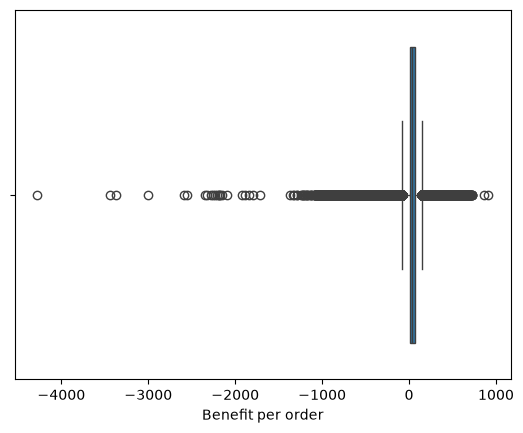

In [24]:
sns.boxplot(x=df["Benefit per order"])
plt.show()

1. Most of the values are concentrated near 0,but the several extreme values are mainly on negative side <br>
2. these values are outliers and they can be high losses.<br>
3.we cannot remove outliers bcoz they can be genuine losses.

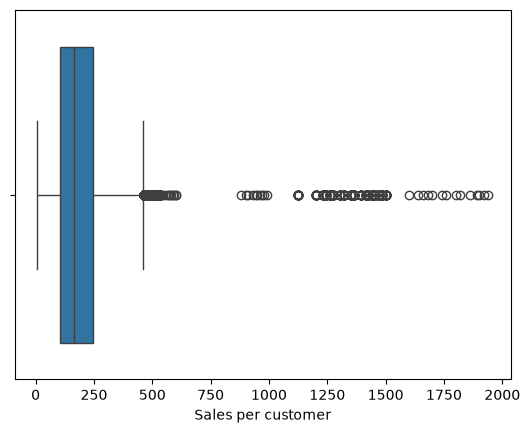

In [25]:
sns.boxplot(x=df["Sales per customer"])
plt.show()

1.Most values are concentrated roughly between 0 and 250.<br>
2.There are potential outliers, with some values reaching around 2000.<br>
3.This means the distribution is right-skewed<br>
4.a small number of customers have much higher sales than most customers.<br>
5.we cannot remove outliers bcoz they can be genuine high  value customers.

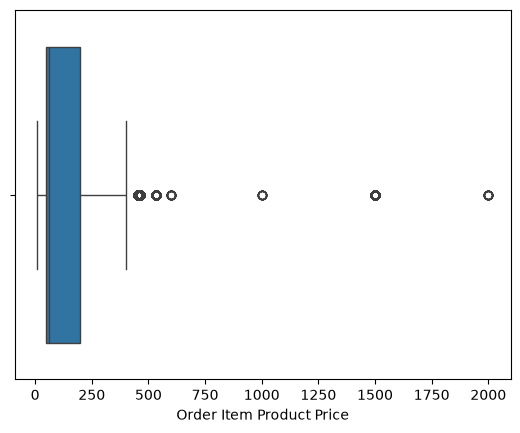

In [26]:
sns.boxplot(x=df["Order Item Product Price"])
plt.show()

1.Most of the product prices are in the lower range.<br>
2.A few products have very high prices.<br>
3.These extreme values are potential outliers.<br>

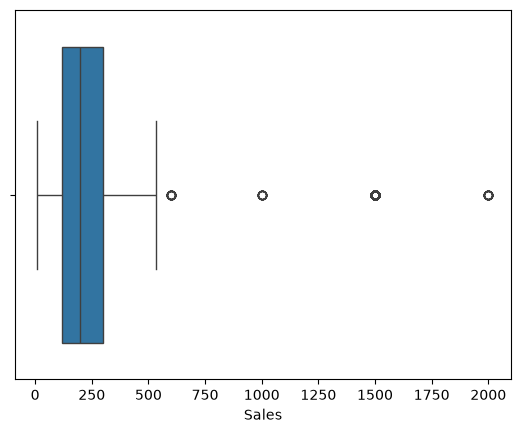

In [27]:
sns.boxplot(x=df["Sales"])
plt.show()

Most sales values are in the lower range.<br>
A few orders have very high sales.<br>
These values are potential outliers.

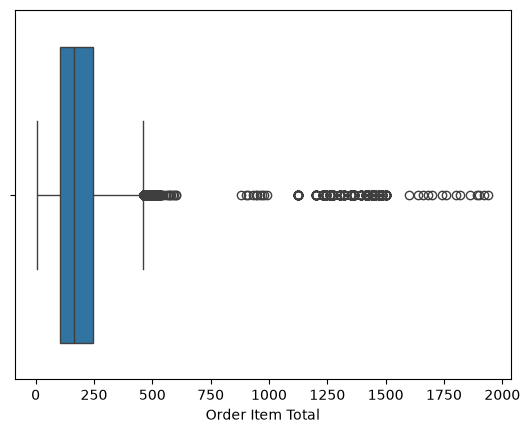

In [28]:
sns.boxplot(x=df["Order Item Total"])
plt.show()

Most order totals are in the lower range.<br>
Some orders have very high total values.<br>
These extreme values are potential outliers.

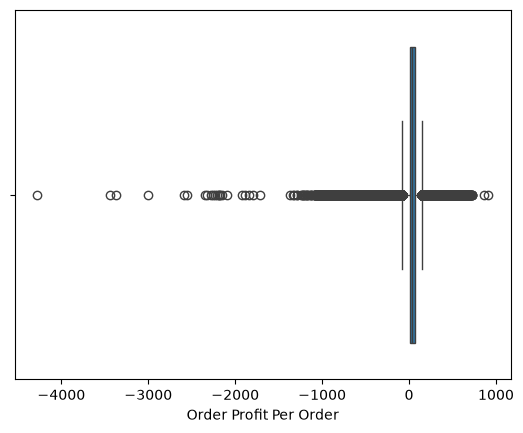

In [29]:
sns.boxplot(x=df["Order Profit Per Order"])
plt.show()

Most profit values are close to 0.<br>
Some orders show very high negative or positive profit.<br>
These extreme values are potential outliers.

### UNIVARIATE ANALYSIS

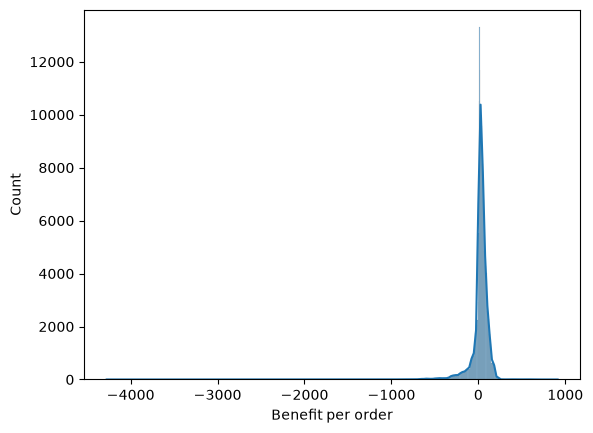

In [30]:
sns.histplot(df["Benefit per order"], kde=True)
plt.show()

Most values are concentrated near 0.<br>
The distribution is right-skewed.<br>
A few extreme values are present on both sides.

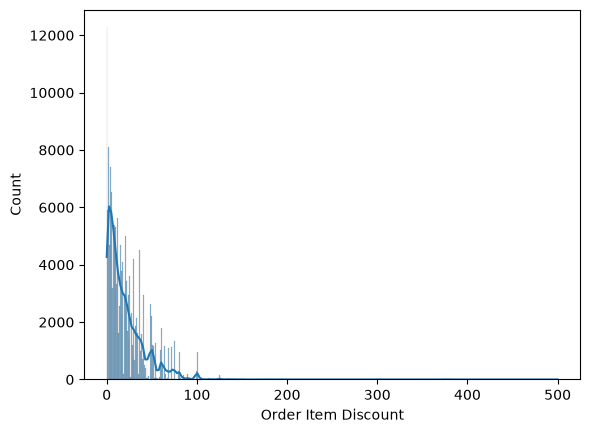

In [31]:
sns.histplot(df["Order Item Discount"], kde=True)
plt.show()

The distribution is right skewed <br>
most of the discount values cconcentrated atlower range .<br>
A few orders have high discount but that can genuine so that we cannot remove that outliers.

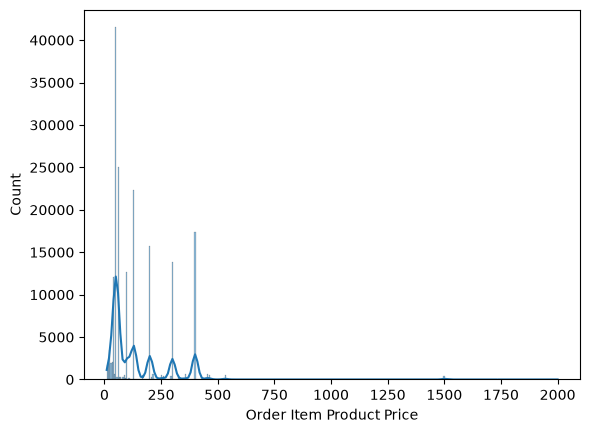

In [32]:
sns.histplot(df["Order Item Product Price"], kde=True)
plt.show()

The distributiion is concentrated at lower product prices.
There are a few products with much higher prices which are outliers

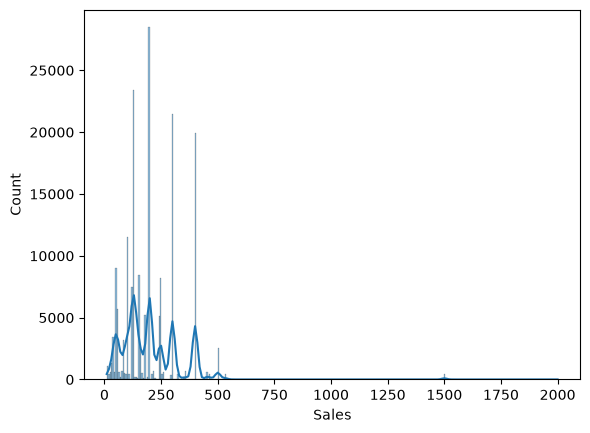

In [33]:
sns.histplot(df["Sales"], kde=True)
plt.show()

The distribution is concentrated in the lower sales range.

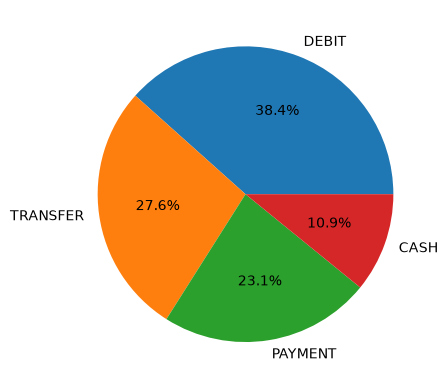

In [54]:
df["Type"].value_counts().plot.pie(autopct="%0.1f%%")
plt.show()

DEBIT transactions are the highest.<br>
TRANSFER is the second highest <br>
CASH transactions are the lowest<br>


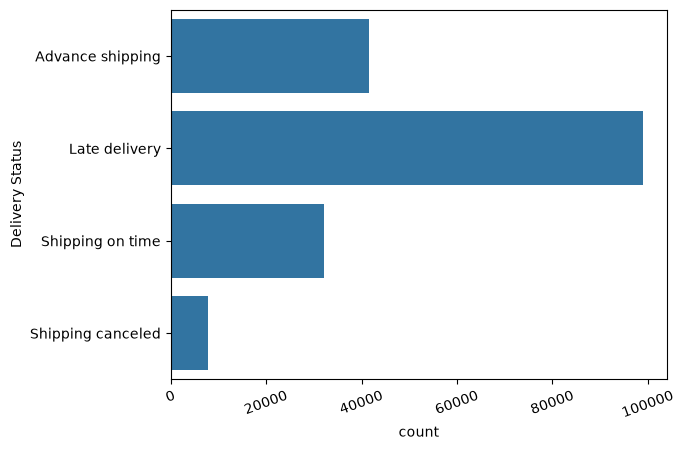

In [35]:
sns.countplot(df["Delivery Status"])
plt.xticks(rotation =20)
plt.show()


Late delivery has the highest number of orders.<br>
Advance shipping is the second highest.<br>
Shipping canceled has the lowest count.<br>


### BIVARIATE ANALYSIS

<Axes: >

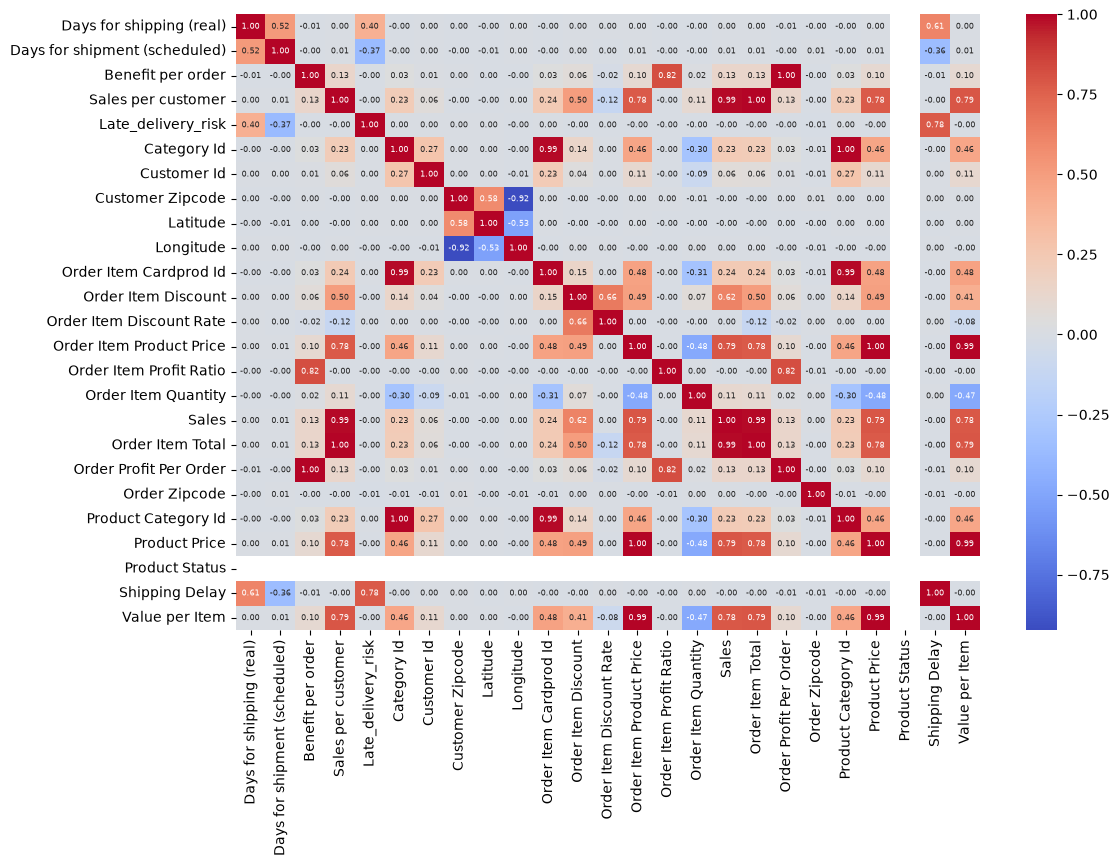

In [57]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only = True) , annot =True , fmt = '.2f' , cmap = 'coolwarm' , annot_kws = {'size':6})

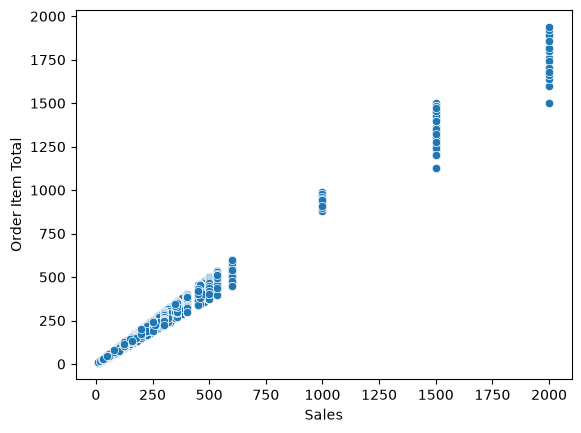

In [37]:
sns.scatterplot(x=df["Sales"], y=df["Order Item Total"])
plt.show()

As sales increses,order item total total also increases<br>
the correlation in heatmap which is positive 0.99

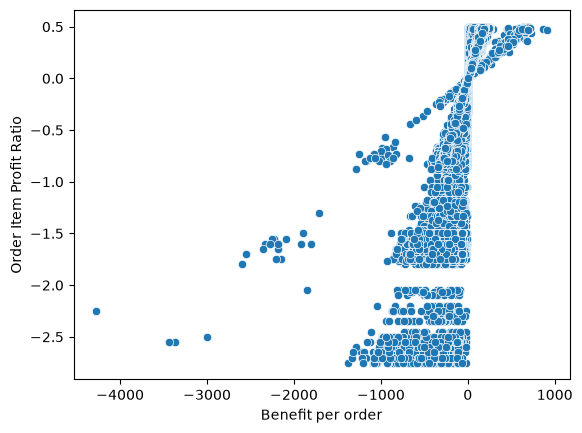

In [38]:
sns.scatterplot(x=df["Benefit per order"], y=df["Order Item Profit Ratio"])
plt.show()

higher benefit values are generally having higher profit ratio<br>
there are some extreme values on negative side

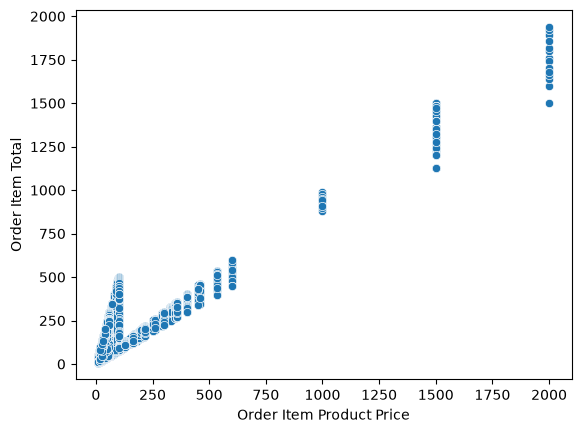

In [39]:
sns.scatterplot(x=df["Order Item Product Price"], y=df["Order Item Total"])
plt.show()

order item product price and order item total show a strong positive relationship.<br>
higher product price generally lead to higher order item total

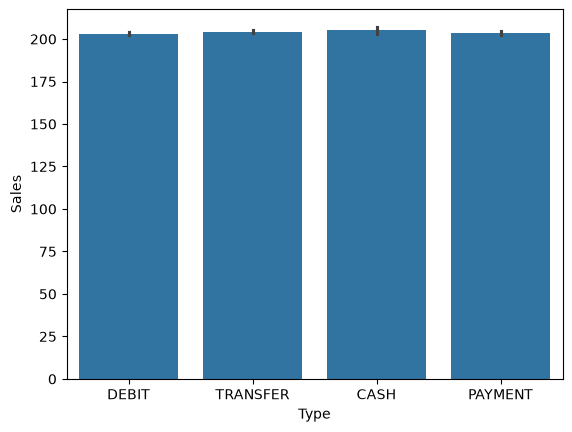

In [40]:
sns.barplot(x=df["Type"],y=df["Sales"])
plt.show()

sales are almost similar across all transaction types

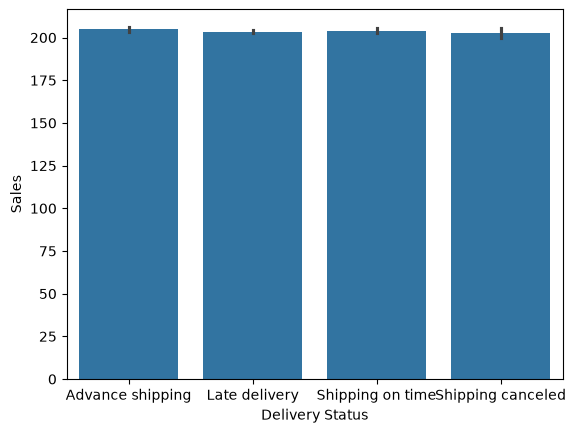

In [41]:
sns.barplot(x=df["Delivery Status"],y=df["Sales"])
plt.show()

### multivariate analysis

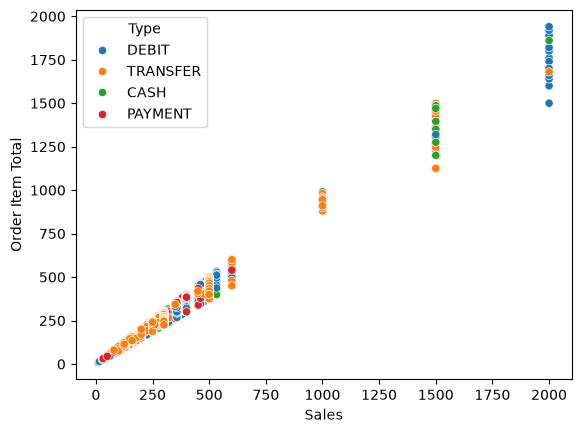

In [42]:
sns.scatterplot(x=df["Sales"], y=df["Order Item Total"], hue=df["Type"])
plt.show()

Sales and order item total have clear positive relation.<br>
In diff payment method the relation is positive.


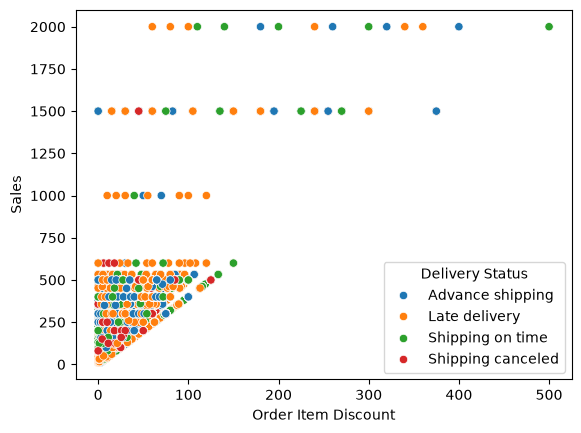

In [43]:
sns.scatterplot(x=df["Order Item Discount"], y=df["Sales"], hue=df["Delivery Status"])
plt.show()

There is a positive relationship between Order Item Discount and Sales.<br>
Different Delivery Status categories are compared using colors.<br>
Higher discount values generally show higher Sales values.

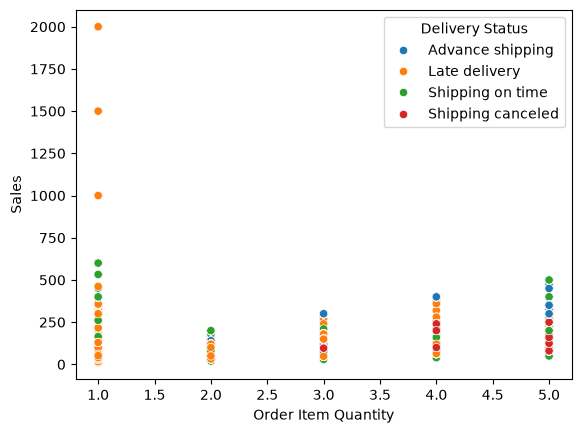

In [44]:
sns.scatterplot(x=df["Order Item Quantity"], y=df["Sales"], hue=df["Delivery Status"])
plt.show()

Sales generally increase as Order Item Quantity increases.<br>
Late delivery has some of the highest Sales values.

### feature engineering

In [45]:
df["Shipping Delay"] = df["Days for shipping (real)"] - df["Days for shipment (scheduled)"]

In [46]:
df["Shipping Delay"].value_counts().sort_index()

Shipping Delay
-2    21666
-1    21700
 0    33751
 1    60646
 2    28718
 3     7052
 4     6983
Name: count, dtype: int64

Most orders have positive shipping delay, with 1 day having most common delay(60,646).<br>
Negative values indicate that some orders were shipped earlier than scheduled.

In [47]:
df["Value per Item"] = df["Order Item Total"] / df["Order Item Quantity"]

value per item represents the value of a single item in an order.<br>
it helps compare order values independent of the quantity purchased.

<Axes: >

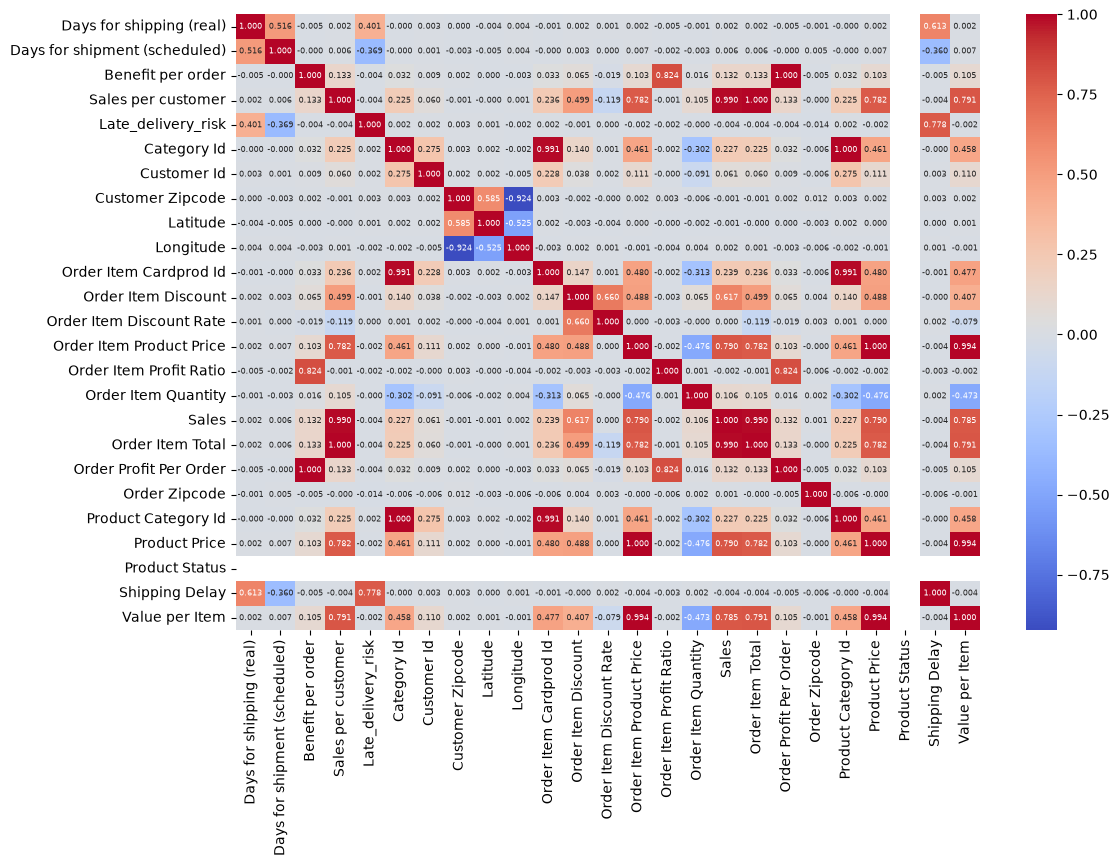

In [48]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only = True) , annot =True , fmt = '.3f' , cmap = 'coolwarm' , annot_kws = {'size':6})

### PCA